In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install chromadb
# !pip install anthropic
# !pip install google-generativeai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 11.9 MB/s et

In [ ]:
# LOT-장비 배정 질의 응답 시스템 (RAG + Chroma + OpenAI API)
import os
from openai import OpenAI
import anthropic
import google.generativeai as genai
import chromadb
import chromadb.utils.embedding_functions as embedding_functions
import pandas as pd
from datetime import datetime
import logging
from pathlib import Path
import re

# 로깅 설정
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class EquipmentAssignmentRAG:
    def __init__(self, api_key=None, csv_path=None, policy_doc_path=None, model_type=None):
        """
        model_type: 'openai' | 'claude' | 'gemini'
        """
        # 1. 클라이언트 설정
        self.gpt_api_key = 'YOUR-API-KEY'

        self.model_type = model_type.lower()
        self.api_key = api_key
        if not self.api_key:
            raise ValueError("OpenAI API Key error")

        if self.model_type == "openai":
            if not self.api_key:
                raise ValueError("OpenAI API Key error")
            self.client_openai = OpenAI(api_key=self.api_key)

        elif self.model_type == "claude":
            if not self.api_key:
                raise ValueError("Anthropic API Key error")
            self.client_claude = anthropic.Anthropic(api_key=self.api_key)

        elif self.model_type == "gemini":
            if not self.api_key:
                raise ValueError("Gemini API Key error")
            genai.configure(api_key=self.api_key)
            self.client_gemini = genai.GenerativeModel(model_name="gemini-2.0-flash")

        else:
            raise ValueError("지원하지 않는 모델 유형입니다. ('openai' | 'claude' | 'gemini')")


        # 3. CSV 데이터 로딩
        self.df = None
        if csv_path:
            self.load_csv_data(csv_path)


    def load_csv_data(self, csv_path):
        """CSV 데이터 로딩 및 전처리"""
        try:
            self.df = pd.read_csv(csv_path)
            # timestamp 컬럼을 datetime으로 변환
            if 'timestamp' in self.df.columns:
                self.df['timestamp'] = pd.to_datetime(self.df['timestamp'], errors='coerce')
            logger.info(f"CSV 데이터 로딩 완료: {len(self.df)} 행")
            logger.info(f"컬럼: {list(self.df.columns)}")
        except Exception as e:
            logger.error(f"CSV 파일 로딩 실패: {e}")
            raise


    def extract_identifiers_from_question(self, question):
        """질문에서 LOT ID, EQUIPMENT ID, timestamp 추출"""
        words = question.split()
        question_upper = question.upper()

        # LOT ID 추출 (L로 시작하는 3-4자리 숫자)
        lot_id = None
        lot_patterns = [
            r'\bL\d{3,4}\b',  # L026, L1234 등
            r'LOT\s*L\d{3,4}',  # LOT L026 등
        ]
        for pattern in lot_patterns:
            matches = re.findall(pattern, question_upper)
            if matches:
                lot_id = matches[0].replace('LOT ', '').strip()
                break

        # EQUIPMENT ID 추출 (E로 시작하는 3-4자리 숫자)
        equipment_id = None
        equipment_patterns = [
            r'\bE\d{3,4}\b',  # E105, E1234 등
            r'장비\s*E\d{3,4}',  # 장비 E105 등
            r'EQUIPMENT\s*E\d{3,4}',  # EQUIPMENT E105 등
        ]
        for pattern in equipment_patterns:
            matches = re.findall(pattern, question_upper)
            if matches:
                equipment_id = matches[0].replace('장비 ', '').replace('EQUIPMENT ', '').strip()
                break

        # timestamp 추출 (더 정교한 패턴 매칭)
        timestamp = None
        timestamp_patterns = [
            r'\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}',  # 2025-06-03 05:00:00
            r'\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}',        # 2025-06-03 05:00
            r'\d{4}/\d{2}/\d{2}\s+\d{2}:\d{2}:\d{2}',  # 2025/06/03 05:00:00
            r'\d{4}/\d{2}/\d{2}\s+\d{2}:\d{2}',        # 2025/06/03 05:00
        ]

        for pattern in timestamp_patterns:
            matches = re.findall(pattern, question)
            if matches:
                try:
                    timestamp = pd.to_datetime(matches[0])
                    break
                except:
                    continue

        # timestamp가 없다면 더 유연한 방법으로 시도
        if timestamp is None:
            for word in words:
                if any(char in word for char in ['-', ':']):
                    try:
                        # 시간 정보가 포함된 단어들을 조합
                        potential_time = word
                        word_idx = words.index(word)
                        if word_idx + 1 < len(words) and ':' in words[word_idx + 1]:
                            potential_time += ' ' + words[word_idx + 1]

                        timestamp = pd.to_datetime(potential_time, errors='coerce')
                        if not pd.isna(timestamp):
                            break
                    except:
                        continue

        logger.info(f"추출된 식별자 - LOT ID: {lot_id}, Equipment ID: {equipment_id}, Timestamp: {timestamp}")
        return lot_id, equipment_id, timestamp

    def find_matching_data(self, lot_id=None, equipment_id=None, timestamp=None, time_tolerance_minutes=30):
        """LOT ID, Equipment ID, timestamp에 매칭되는 데이터 찾기"""
        if self.df is None:
            return pd.DataFrame()

        matched = self.df.copy()
        applied_filters = []

        # LOT ID 필터링
        if lot_id:
            matched = matched[matched["lot_id"] == lot_id]
            applied_filters.append(f"LOT ID: {lot_id}")

        # Equipment ID 필터링
        if equipment_id:
            matched = matched[matched["equipment_id"] == equipment_id]
            applied_filters.append(f"Equipment ID: {equipment_id}")

        # timestamp 필터링 (허용 오차 범위 내)
        if timestamp is not None and not matched.empty:
            timestamp_cols = []
            if 'timestamp' in matched.columns:
                timestamp_cols.append('timestamp')

            best_matches = []
            for ts_col in timestamp_cols:
                if ts_col in matched.columns:
                    matched_copy = matched.copy()
                    matched_copy['time_diff'] = abs(matched_copy[ts_col] - timestamp).dt.total_seconds() / 60  # 분 단위

                    # 허용 오차 범위 내의 데이터만 선택
                    within_tolerance = matched_copy[matched_copy['time_diff'] <= time_tolerance_minutes]
                    if not within_tolerance.empty:
                        best_match = within_tolerance.nsmallest(1, 'time_diff')
                        best_match['matched_timestamp_column'] = ts_col
                        best_matches.append(best_match)

            if best_matches:
                # 가장 시간 차이가 적은 매치 선택
                all_matches = pd.concat(best_matches)
                matched = all_matches.nsmallest(1, 'time_diff')
                applied_filters.append(f"Timestamp: {timestamp} (±{time_tolerance_minutes}분)")
            else:
                # 허용 오차 범위 내에 없다면 가장 가까운 시간 찾기
                if timestamp_cols:
                    for ts_col in timestamp_cols:
                        if ts_col in matched.columns:
                            matched['time_diff'] = abs(matched[ts_col] - timestamp).dt.total_seconds() / 60
                            matched = matched.nsmallest(1, 'time_diff')
                            matched['matched_timestamp_column'] = ts_col
                            break
                    applied_filters.append(f"Timestamp: {timestamp} (가장 가까운 시간)")

        logger.info(f"적용된 필터: {', '.join(applied_filters) if applied_filters else '없음'}")
        logger.info(f"매칭된 데이터 개수: {len(matched)}")

        return matched

    def format_matched_data(self, matched_df):
        """매칭된 데이터를 보기 좋게 포맷팅"""
        if matched_df.empty:
            return "조건에 맞는 데이터를 찾을 수 없습니다."

        result_texts = []
        for idx, row in matched_df.iterrows():
            # 사용된 timestamp 컬럼 확인
            ts_col = row.get('matched_timestamp_column', 'timestamp')
            timestamp_value = row.get(ts_col, row.get('timestamp', 'N/A'))

            result_text = f"""
[LOT {row.get('lot_id', 'N/A')}] - [장비 {row.get('equipment_id', 'N/A')}] ({timestamp_value} 시점):
- 상태: {row.get('status', 'N/A')}
- 현재 공정: {row.get('current_process', 'N/A')}
- 현재 WIP: {row.get('current_wip', 'N/A')} (최소 필요: {row.get('min_required_wip', 'N/A')})
- 처리 중인 LOT: {row.get('processing_lot', 'N/A')}
- 최근 평균 처리시간: {row.get('recent_avg_proc_time_min', 'N/A')}분
- 장비 유형: {row.get('equipment_type', 'N/A')}
- 후보 장비: {row.get('equipment_candidate', 'N/A')}
- 우선순위: {row.get('priority', 'N/A')}
- 긴급 여부: {'긴급' if str(row.get('is_hot', '')).lower() in ['true', '1', 'yes'] else '일반'}
- 배정 사유: {row.get('assignment_reason', 'N/A')}
            """
            result_texts.append(result_text.strip())

        return "\n\n".join(result_texts)

    def answer_equipment_assignment(self, question: str, k: int = 3) -> str:
        """질의응답 메인 함수"""
        try:

            # 2. LOT ID, Equipment ID, timestamp 추출
            lot_id, equipment_id, timestamp = self.extract_identifiers_from_question(question)

            # 3. 데이터 매칭
            matched = self.find_matching_data(lot_id, equipment_id, timestamp)

            # 4. 매칭된 데이터 포맷팅
            formatted_data = self.format_matched_data(matched)
            # print(formatted_data)

            # 5. 추가 컨텍스트 정보 수집
            context_info = []
            if lot_id and not matched.empty:
                # 해당 LOT의 다른 시점 데이터
                lot_history = self.df[self.df['lot_id'] == lot_id].head(5)
                if len(lot_history) > 1:
                    context_info.append(f"LOT {lot_id}의 최근 이력 개수: {len(lot_history)}")

            if equipment_id and not matched.empty:
                # 해당 장비의 최근 상태
                equip_history = self.df[self.df['equipment_id'] == equipment_id].head(5)
                if len(equip_history) > 1:
                    context_info.append(f"장비 {equipment_id}의 최근 이력 개수: {len(equip_history)}")

            # 6. 프롬프트 생성 및 응답
            prompt = f"""당신은 반도체 공정 LOT-장비 스케줄링 전문가입니다.
다음은 스케줄링 문서 및 실제 배정 데이터입니다:

[실제 배정 데이터]
{formatted_data}

[추가 컨텍스트]
{', '.join(context_info) if context_info else '추가 정보 없음'}

사용자 질문: {question}

위의 정보를 바탕으로 다음 관점에서 분석하여 설명해주세요:

1. **실제 배정 결과 및 배정 가능 설비**: 해당 시점에 실제로 배정된 장비와 배정이 가능했던 장비(Available 혹은 Busy)
2. **Lot 특성 파악**: Hot Lot 여부 파악
3. **장비 상태 파악**: 실제 배정 장비와 후보들의 해당 시점 status, current_wip을 파악
4. **배정 최적화 요소**: 왜 이 장비가 선택되었고, 다른 후보 장비 대비 장점

구체적인 수치와 조건을 언급하며 한국어로 명확하고 간결하게 답변해주세요."""

            if self.model_type == "openai":
                response = self.client_openai.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.2,
                    max_tokens=2000
                )
                return response.choices[0].message.content.strip()

            elif self.model_type == "claude":
                response = self.client_claude.messages.create(
                    model="claude-3-haiku-20240307",
                    max_tokens=2000,
                    temperature=0.2,
                    messages=[{
                        "role": "user",
                        "content": prompt
                    }]
                )
                return response.content[0].text.strip()

            elif self.model_type == "gemini":
                response = self.client_gemini.generate_content(prompt)
                return response.text.strip()

        except Exception as e:
            logger.error(f"질의응답 처리 중 오류 발생: {e}")
            return f"질의응답 처리 중 오류가 발생했습니다: {str(e)}"


In [ ]:
# API 키 설정 (실제 사용시 환경변수 또는 안전한 방법으로 관리)
# api_key = "YOUR-API-KEY" # openai api
# api_key = 'YOUR-API-KEY' # claude api
api_key = 'YOUR-API-KEY' # gemini api

doc_paths = [
    "/content/drive/MyDrive/bkms1/1_스케줄링_기본_단위_및_범위.txt",
    "/content/drive/MyDrive/bkms1/2_장비_할당_및_배정_정책.txt",
    "/content/drive/MyDrive/bkms1/2_1_장비_로드_밸런싱.txt",
    "/content/drive/MyDrive/bkms1/3_LOT_우선순위_결정_로직.txt",
    "/content/drive/MyDrive/bkms1/4_공정_간_순서_및_제약_조건.txt",
    "/content/drive/MyDrive/bkms1/5_설비_유지보수_및_장애_반영.txt",
    "/content/drive/MyDrive/bkms1/6_알고리즘_구조_및_기술적_구현.txt"
]

# 시스템 초기화
rag_system = EquipmentAssignmentRAG(
    api_key=api_key,
    csv_path="/content/drive/MyDrive/bkms1/full_log.csv",
    policy_doc_path=doc_paths,
    model_type="gemini" # 'openai' 'claude' 'gemini'
)

In [ ]:
# model_response 생성기
def generate_model_responses(df, rag_system, question_column="question"):
    responses = []
    for question in df[question_column]:
        try:
            response = rag_system.answer_equipment_assignment(question)
        except Exception as e:
            response = f"[ERROR] {e}"
        responses.append(response)
    df["model_response"] = responses
    return df

df = pd.read_csv("/content/drive/MyDrive/bkms1/evaluation_wo_rag_gpt_claude.csv", encoding='cp949')
df

,question,reference_answer,gpt_4o_mini,claude_3_haiku
0,2025-06-03 20:00에 LOT L006이 E109로 할당된 사유가 무엇인지...,2025-06-03 20:00 시점에 LOT L006은 공정 실패로 인해 즉시 재투...,2025-06-03 20:00에 LOT L006이 E109로 할당된 사유를 다음 관...,2025-06-03 20:00에 LOT L006이 E109로 할당된 사유는 다음과 ...
1,LOT L015은 2025-06-03 08:20에 왜 E102 장비로 스케줄링되었나요?,LOT L015은 2025-06-03 08:20 시점에 장비 E102에 배정되었습니...,LOT L015가 2025-06-03 08:20에 E102 장비로 스케줄링된 이유를...,1. **실제 배정 결과 및 배정 가능 설비**:\n - 실제 배정된 장비는 E...
2,2025-06-03 22:30에 LOT L003이 E109로 할당된 사유가 무엇인지...,2025-06-03 22:30 시점에 LOT L003은 공정 실패로 인해 즉시 재투...,2025-06-03 22:30에 LOT L003이 E109로 할당된 사유를 다음과 ...,2025-06-03 22:30에 LOT L003이 E109로 할당된 사유는 다음과 ...
3,장비 E114는 왜 LOT L008을 2025-06-03 18:05에 처리하게 되었나요?,2025-06-03 18:05 시점에 LOT L008은 공정 실패로 인해 즉시 재투...,장비 E114가 LOT L008을 2025-06-03 18:05에 처리하게 된 이유...,장비 E114가 LOT L008을 2025-06-03 18:05에 처리하게 된 이유...
4,2025-06-03 03:15에 LOT L019이 E104로 할당된 사유가 무엇인지...,LOT L019은 2025-06-03 03:15 시점에 장비 E104에 배정되었습니...,2025-06-03 03:15에 LOT L019이 E104로 할당된 사유를 다음과 ...,2025-06-03 03:15에 LOT L019이 E104로 할당된 사유는 다음과 ...
...,...,...,...,...
95,왜 LOT L001은 2025-06-03 02:25 시점에 장비 E114에는 배정되...,2025-06-03 02:25 시점에 LOT L001은 장비 E114 대신 E111...,LOT L001이 2025-06-03 02:25 시점에 장비 E114에 배정되지 않...,2025-06-03 02:25 시점에 LOT L001이 장비 E114에 배정되지 않...
96,"E106가 아닌 E101가 선택된 이유는 무엇인가요? (LOT L027, 2025-...",2025-06-03 14:45 시점에 LOT L027은 장비 E106 대신 E101...,"LOT L027의 경우, E101이 선택된 이유를 다음과 같은 관점에서 분석할 수 ...",이 상황에서 LOT L027이 E101 장비에 배정된 이유는 다음과 같습니다:\n\...
97,LOT L002은 2025-06-03 11:15에 E105 장비로 배정되지 않은 이...,2025-06-03 11:15 시점에 LOT L002은 장비 E105 대신 E109...,LOT L002이 2025-06-03 11:15에 E105 장비로 배정되지 않은 이...,죄송합니다. 제가 분석할 수 있는 정보가 충분하지 않습니다. 실제 배정 데이터가 없...
98,장비 E113가 2025-06-03 09:25 시점에 LOT L019을 처리하지 않...,2025-06-03 09:25 시점에 LOT L019은 장비 E113 대신 E114...,장비 E113가 2025-06-03 09:25 시점에 LOT L019을 처리하지 않...,장비 E113이 2025-06-03 09:25 시점에 LOT L019을 처리하지 않...


In [ ]:
# 모델 응답 생성 (rag_system 인스턴스를 만들고 아래 함수에 전달)
df = generate_model_responses(df, rag_system)

# 결과 저장
df.to_csv("/content/drive/MyDrive/bkms1/evaluation_wo_rag_gpt_claude_gemini.csv", index=False, encoding='cp949')

# gold standard과 각 모델의 답변 간 추론 방식이 얼마나 유사한지 판단 - claude 3.5 sonnet model as a judge

In [ ]:
!pip install openai==0.28

In [ ]:
import pandas as pd
# import anthropic
import openai
import time

# Claude API 설정
#claude_client = anthropic.Anthropic(api_key="YOUR-API-KEY")

# OpenAI API 설정
openai.api_key = "YOUR-API-KEY"

# 평가 대상 모델 열
model_cols = ['gpt_4o_mini', 'claude_3_haiku', 'gemini_2.0_flash']

# 프롬프트 생성 함수
def build_prompt(question, reference, candidate):
    return f"""
당신은 전문가입니다. 아래는 하나의 질문, 전문가의 정답(reference), 그리고 AI의 응답(candidate)입니다.

질문:
{question}

전문가의 정답(reference):
{reference}

AI의 응답(candidate):
{candidate}

이 AI 응답이 전문가의 정답과 추론 방식과 결론이 얼마나 유사한지 0~10점으로 평가해주세요.

- 10점: 추론 흐름과 결론이 모두 전문가 수준으로 유사함
- 8~9점: 거의 유사하나 일부 세부 논리나 표현이 다름
- 6~7점: 결론은 맞지만 추론 흐름이 다소 다름
- 4~5점: 결론 일부가 다르며, 추론 흐름도 부분적으로 다름
- 1~3점: 추론 및 결론이 거의 다름
- 0점: 전혀 맞지 않음

단답형 숫자만 출력해주세요.
"""

# 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/bkms1/evaluation_wo_rag_gpt_claude_gemini.csv", encoding='cp949')

# 평가 수행
for idx, row in df.iterrows():
    question = row['question']
    reference = row['reference_answer']

    for col in model_cols:
        candidate = row[col]
        prompt = build_prompt(question, reference, candidate)

        # # Claude 평가
        # try:
        #     claude_response = claude_client.messages.create(
        #         model="claude-3-5-sonnet-20240620",
        #         max_tokens=10,
        #         temperature=0,
        #         messages=[{"role": "user", "content": prompt}]
        #     )
        #     claude_score_text = claude_response.content[0].text.strip()
        #     claude_score = float(claude_score_text) if claude_score_text.replace('.', '', 1).isdigit() else -1
        # except Exception as e:
        #     print(f"Claude Error at row {idx} for {col}: {e}")
        #     claude_score = -1

        # df.loc[idx, f"{col}_claude_score"] = claude_score

        # GPT-4o 평가
        try:
            gpt_response = openai.ChatCompletion.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=10,
                temperature=0
            )
            gpt_score_text = gpt_response['choices'][0]['message']['content'].strip()
            gpt_score = float(gpt_score_text) if gpt_score_text.replace('.', '', 1).isdigit() else -1
        except Exception as e:
            print(f"GPT-4o Error at row {idx} for {col}: {e}")
            gpt_score = -1

        df.loc[idx, f"{col}_gpt4o_score"] = gpt_score

        time.sleep(20)  # API rate limit 대응
        print(idx)

# 저장
df.to_csv("/content/drive/MyDrive/bkms1/evaluation_db_with_gpt4o_score.csv", index=False, encoding='cp949')

# 결과 시각화

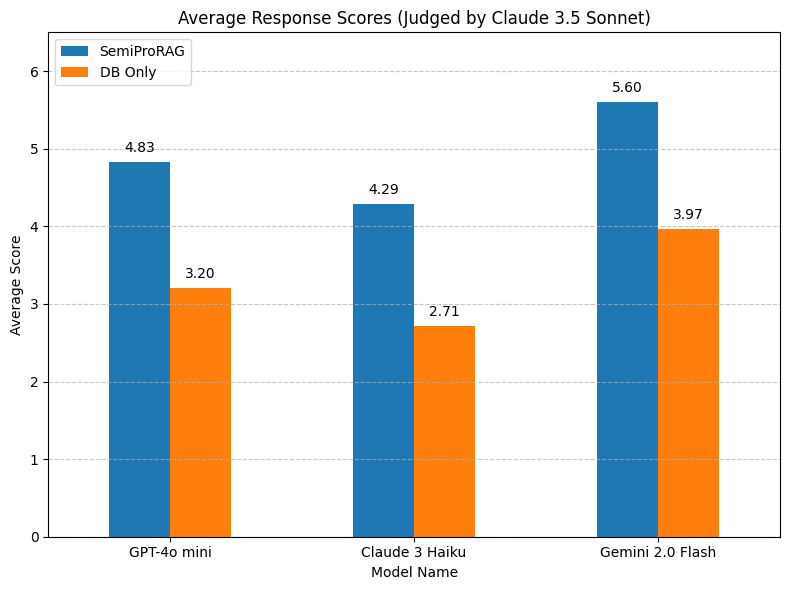

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 불러오기
semipro_df = pd.read_csv('/content/drive/MyDrive/bkms1/evaluation_semipro_score_10pt.csv', encoding='cp949')
db_only_df = pd.read_csv('/content/drive/MyDrive/bkms1/evaluation_db_only_score_10pt.csv', encoding='cp949')

# 사용할 열 지정
columns_to_plot = ['gpt_4o_mini_claude_score', 'claude_3_haiku_claude_score', 'gemini_2.0_flash_claude_score']

# 평균 계산
semipro_means = semipro_df[columns_to_plot].mean()
db_only_means = db_only_df[columns_to_plot].mean()

# 비교용 데이터프레임 생성
comparison_df = pd.DataFrame({
    'SemiProRAG': semipro_means,
    'DB Only': db_only_means
}, index=columns_to_plot)

# x축 레이블 매핑
label_mapping = {
    'gpt_4o_mini_claude_score': 'GPT-4o mini',
    'claude_3_haiku_claude_score': 'Claude 3 Haiku',
    'gemini_2.0_flash_claude_score': 'Gemini 2.0 Flash'
}
comparison_df.index = comparison_df.index.map(label_mapping)

# 그래프 그리기
ax = comparison_df.plot(kind='bar', figsize=(8, 6))
ax.set_title('Average Response Scores (Judged by Claude 3.5 Sonnet)')
ax.set_ylabel('Average Score')
ax.set_xlabel('Model Name')
ax.set_xticklabels(comparison_df.index, rotation=0)
ax.set_ylim(0, 6.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 점수 표시
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
semipro_means

,0
gpt_4o_mini_claude_score,4.14
claude_3_haiku_claude_score,3.55
gemini_2.0_flash_claude_score,4.93


In [ ]:
db_only_means

,0
gpt_4o_mini_claude_score,2.13
claude_3_haiku_claude_score,1.39
gemini_2.0_flash_claude_score,3.03
